## Introduction

This project is about predicting whether a loan will be approved or not.
We use a dataset of loan applicants and apply Logistic Regression to build a simple prediction model.


In [2]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

## Dataset Description

The dataset contains information about loan applicants such as income, gender, marital status, and loan amount.

Target variable:

* Loan_Status (Y = Approved, N = Not Approved)


In [3]:
#  Load Dataset
from google.colab import files
uploaded = files.upload()



Saving train_u6lujuX_CVtuZ9i.csv to train_u6lujuX_CVtuZ9i.csv


In [4]:
df = pd.read_csv("train_u6lujuX_CVtuZ9i.csv")

print(df.head())
print(df.shape)

    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001002   Male      No          0      Graduate            No   
1  LP001003   Male     Yes          1      Graduate            No   
2  LP001005   Male     Yes          0      Graduate           Yes   
3  LP001006   Male     Yes          0  Not Graduate            No   
4  LP001008   Male      No          0      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   
3             2583             2358.0       120.0             360.0   
4             6000                0.0       141.0             360.0   

   Credit_History Property_Area Loan_Status  
0             1.0         Urban           Y  
1             1.0         Rural           N  
2             1.0   

## Data Preprocessing

* Filled missing values using mean and mode
* Converted categorical data into numeric form
* Selected important features for the model


In [5]:

# 3. Handle Missing Values

df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])
df['Married'] = df['Married'].fillna(df['Married'].mode()[0])
df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].mean())

# Convert to numeric
df['Gender'] = df['Gender'].map({'Male':1, 'Female':0})
df['Married'] = df['Married'].map({'Yes':1, 'No':0})
df['Loan_Status'] = df['Loan_Status'].map({'Y':1, 'N':0})

In [6]:
print(df['Gender'].unique())
print(df['Married'].unique())

[1 0]
[0 1]


## Exploratory Data Analysis

* Used histogram to check loan distribution
* Used scatter plot to see relation between income and loan amount


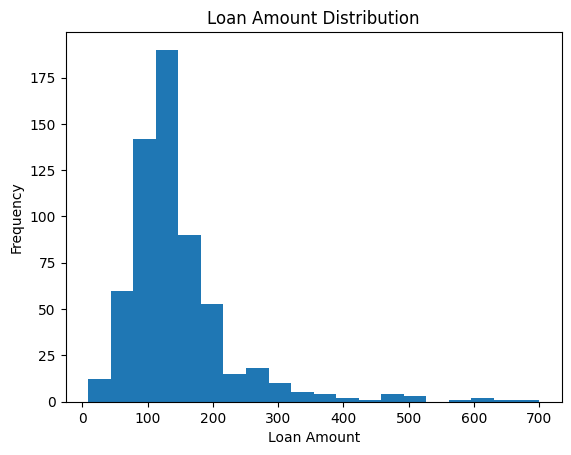

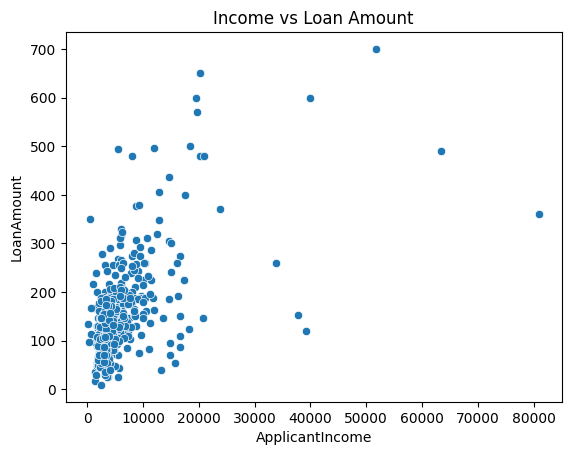

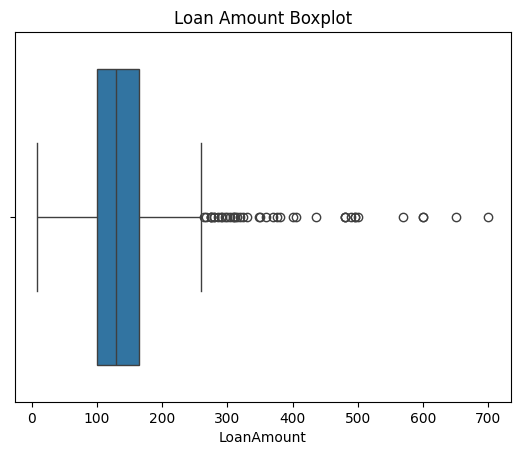

In [7]:

# Histogram (Loan Amount)
plt.hist(df['LoanAmount'], bins=20)
plt.title("Loan Amount Distribution")
plt.xlabel("Loan Amount")
plt.ylabel("Frequency")
plt.show()

# Scatter Plot (Income vs Loan)
sns.scatterplot(x='ApplicantIncome', y='LoanAmount', data=df)
plt.title("Income vs Loan Amount")
plt.show()

# Boxplot (to check outliers)
sns.boxplot(x=df['LoanAmount'])
plt.title("Loan Amount Boxplot")
plt.show()

In [8]:
# Preparing Data

X = df[['ApplicantIncome', 'LoanAmount', 'Gender', 'Married']]
y = df['Loan_Status']

print(X.head())
print(y.head())

   ApplicantIncome  LoanAmount  Gender  Married
0             5849  146.412162       1        0
1             4583  128.000000       1        1
2             3000   66.000000       1        1
3             2583  120.000000       1        1
4             6000  141.000000       1        0
0    1
1    0
2    1
3    1
4    1
Name: Loan_Status, dtype: int64


## Model Training

* Used Logistic Regression
* Split data into training and testing sets
* Trained model on selected features


In [12]:
# Train/Test/Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (491, 4)
Testing data: (123, 4)


In [13]:
# Training Model
model = LogisticRegression(class_weight='balanced')
model.fit(X_train, y_train)

print("Model trained successfully")

Model trained successfully


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [14]:
#Predictions
y_pred = model.predict(X_test)

print(y_pred[:10])  # first 10 predictions

[1 1 1 0 0 1 1 1 1 1]


## Model Evaluation

* Checked accuracy score
* Used confusion matrix to evaluate predictions


In [16]:
# Model Evaluation
from sklearn.metrics import accuracy_score, confusion_matrix

accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("Accuracy:", accuracy)
print("Confusion Matrix:\n", cm)

Accuracy: 0.5691056910569106
Confusion Matrix:
 [[14 29]
 [24 56]]


## Conclusion

* Logistic Regression was used for loan prediction
* Initial model was biased toward approved cases
* Class balancing improved prediction of both classes
* Final accuracy ≈ 57% with better class distribution
* Income and loan amount are key factors
